# ToE Demonstartion on GMST

This notebook is designed to be both technically reproducible and presentation-friendly.


<div class="nb-card nb-accent">
  <strong>Notebook Goal</strong><br>
  Build a transparent, reproducible <em>Time of Emergence</em> workflow on ACCESS ensembles, compare multiple emergence metrics, and generate publication-ready summary figures.
</div>

<div class="nb-card nb-info">
  <strong>What You Will Get</strong><br>
  <span class="nb-chip">GMST anomalies (members + median)</span>
  <span class="nb-chip">S/N families (incl. piControl noise)</span>
  <span class="nb-chip">KS / t-test / overlap metrics</span>
  <span class="nb-chip">Probability Ratio (PR)</span>
  <span class="nb-chip">Merged ToE estimates</span>
  <span class="nb-chip">Core toe_plots panel + helper figures</span>
</div>


Notebook Flow 

<div class="nb-flow">
<b>Step 1:</b> Load ACCESS and piControl datasets  
<b>Step 2:</b> Compute global-mean series and base-period anomalies  
<b>Step 3:</b> Build S/N methods (trend-fit, anomaly, ensemble-median, piControl-noise)  
<b>Step 4:</b> Build statistical and overlap metrics + PR  
<b>Step 5:</b> Apply permanent-exceedance rules to infer ToE year by metric  
<b>Step 6:</b> Plot core ToE panel and communication figures
</div>

 Metric Logic Summary

- **S/N metrics:** emergence when \(|S/N| \ge 1\)
- **KS / t-test:** emergence when p-values cross threshold (`PVALUE_THESHOLD1`)
- **Overlap metrics (`frac`, `hd`):** emergence from overlap/distance threshold (`OVERLAP_THRESHOLD`)
- **PR metric:** emergence when \(PR \ge 2\)
- **`nn` metric:** emergence via permanent boolean exceedance


# Imports and Environment


In [1]:
# Standard library
import os
import sys
import warnings
from importlib import reload
from functools import partial
from typing import Optional, Tuple


In [2]:
# Third-party scientific stack
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


mkdir -p failed for path /scratch/v45/dr4292/tmp/.cache/matplotlib: [Errno 13] Permission denied: '/scratch/v45/dr4292/tmp/.cache'
Matplotlib created a temporary cache directory at /jobfs/173218664.gadi-pbs/matplotlib-s0vajvfn because there was an issue with the default path (/scratch/v45/dr4292/tmp/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
# Local project imports
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts'))
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts', 'src'))

import climate_utils
import my_stats
import toe_plots
import toe_calc as toe
import toe_constants as toe_const
# import open
from toe_constants import PVALUE_THESHOLD1, OVERLAP_THRESHOLD
import constants

In [4]:
warnings.filterwarnings('ignore')
xr.set_options(display_expand_attrs=False)
xr.set_options(display_expand_data=False)

In [5]:
# client.close()

In [6]:
from dask.distributed import Client, wait, LocalCluster
cluster = LocalCluster(threads_per_worker=1, memory_limit=None, n_workers=4);
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39285,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35669,Total threads: 1
Dashboard: /proxy/37493/status,Memory: 0 B
Nanny: tcp://127.0.0.1:44109,


# Loading Datasets

In [7]:
base_period_tuple = (1850, 1880)
window = 30

pr_event_quantile = 0.95
pr_window = window

In [8]:
base_period_length = base_period_tuple[-1] - base_period_tuple[0]
base_period_length

30

Configuration Notes

- `base_period_tuple` defines the reference climate used to center anomalies.
- `window` is the moving-window length used by several statistics.
- PR settings:
  - `pr_event_quantile` defines the exceedance event threshold from the base period.
  - `pr_window` is the rolling window used to estimate time-varying event probability.


 Load ACCESS + piControl


In [9]:
# # ACCESS
# model = 'access'
# experiment = 'ssp585'
# variable = 'tas'#'tas' #pr
# dataset_name = f'{model}_{experiment}'

# CHUNK_DICT = {
#     'best': {'time':-1, 'lat': 180//10, 'lon': 360//10},
#     'access': {'time':-1, 'member':1, 'lat': 72//4, 'lon':-1}
# }
# chunks = CHUNK_DICT[model]

# FILE_NAME = f'/g/data/w40/ab2313/time_of_emergence/{dataset_name}_{variable}.zarr'
# print(FILE_NAME)
# ds = xr.open_dataset(FILE_NAME, engine='zarr', chunks=chunks, use_cftime=True)[variable].persist()
# wait(ds);

In [10]:
import open_data
ds = open_data.open_best()

Opening best dataset from - /g/data/w40/ab2313/time_of_emergence/best/Land_and_Ocean_LatLong1_time_chunk.zarr


  -- overriding time to use cftime
  -- resampling to yearly mean


In [11]:
ds = ds.drop('height', errors='ignore')

In [12]:
# PI_CHUNKS = {'time':-1, 'lat':'auto', 'lon':'auto'}
# version = '04'
# PICONTROL_PATH = os.path.join(constants.TOE_SAVE_DIR, f'access_ssp585_tas_(1880_1909)_{version}/piControl_tas.zarr')
# pi_ds = xr.open_dataset(PICONTROL_PATH, engine='zarr', use_cftime=True).chunk(PI_CHUNKS).persist()['tas']
# wait(pi_ds);
# pi_ds

In [13]:
# Keep this logic exactly as requested
if 'member' in list(ds.coords):
    plotting_dict = {'hue': 'member', 'add_legend': False}
    member_kwargs = {'member':0}
else:
    plotting_dict = {}
    member_kwargs = {}

Data Expectations

This notebook assumes ACCESS-like ensemble structure with a `member` dimension.

For `pi_ds`, you only need a dataset that can be reduced to a global mean and has enough samples to estimate variability noise.


 Global Mean and Base-Period Anomalies


In [14]:
# Global mean (ensemble members retained)
smean_ds = climate_utils.weighted_lat_lon_mean(ds)

In [15]:
if 'member' in list(smean_ds.coords):
    smean_ds = smean_ds.chunk({'time':-1, 'member': 10}).persist()
else:
    smean_ds = smean_ds.compute()

In [16]:
smean_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 700B
-0.3587 -0.2924 -0.2442 -0.26 -0.2723 ... 1.025 0.8704 0.9127 1.204 1.273
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [17]:
# pi_smean_ds = climate_utils.weighted_lat_lon_mean(pi_ds).compute()

 Why Global Mean First?

The ToE workflow here is intentionally 1D in time:

1. reduce each member to global mean,
2. build anomaly time series,
3. run distribution and threshold metrics consistently across methods.

This keeps all methods comparable and makes interpretation straightforward.


In [18]:
# Restrict to configured start year
smean_ds = smean_ds.sel(time=smean_ds.time.dt.year >= base_period_tuple[0])

In [19]:
# Base-period subset
base_period_ds = smean_ds.where(
    smean_ds.time.dt.year.isin(np.arange(*base_period_tuple)),
    drop=True,
)
base_period_ds

<xarray.DataArray 'temperature' (time: 30)> Size: 120B
-0.3587 -0.2924 -0.2442 -0.26 -0.2723 ... -0.3081 -0.3222 0.0477 0.1164 -0.1994
Coordinates:
  * time     (time) object 240B 1850-12-31 00:00:00 ... 1879-12-31 00:00:00

In [20]:
# Convert to anomalies relative to base-period mean
smean_anom_ds = smean_ds - base_period_ds.mean(dim='time').persist()
base_period_anom_ds = base_period_ds - base_period_ds.mean(dim='time').persist()

wait(smean_anom_ds);
wait(base_period_anom_ds);

In [21]:
base_period_anom_ds

<xarray.DataArray 'temperature' (time: 30)> Size: 240B
-0.08897 -0.02272 0.02549 0.009677 -0.002542 ... -0.05252 0.3174 0.3861 0.07033
Coordinates:
  * time     (time) object 240B 1850-12-31 00:00:00 ... 1879-12-31 00:00:00

Checkpoint: Preprocessing Sanity Check

Use this block to verify:
- member count,
- time span,
- anomaly centering,
- median extraction.


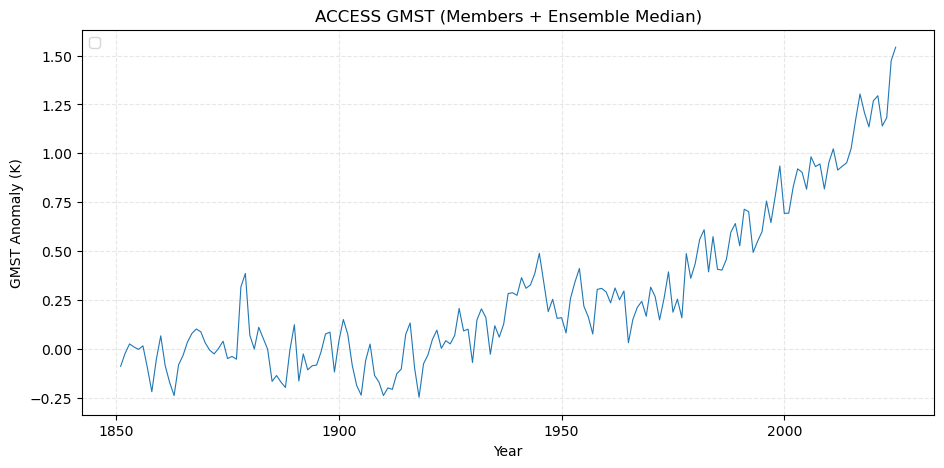

In [22]:
# Quick visual check: all members + median
fig, ax = plt.subplots(figsize=(11, 5))
smean_anom_ds.plot(ax=ax, linewidth=0.8, **plotting_dict)
ax.set_xlabel('Year')
ax.set_ylabel('GMST Anomaly (K)')
ax.set_title('ACCESS GMST (Members + Ensemble Median)')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left')

In [23]:
print('smean_anom_ds dims:', smean_anom_ds.dims)
print('smean_anom_ds shape:', tuple(smean_anom_ds.shape))

# base-period mean should be near zero after anomaly conversion
base_mean_check = base_period_anom_ds.mean(dim=['time']).values.astype(float)
print('base-period mean (should be ~0):', np.round(base_mean_check, 6))

smean_anom_ds dims: ('time',)
smean_anom_ds shape: (175,)
base-period mean (should be ~0): -0.0


# ToE Metric Calculations

## Signal-to-Noise 



We compute multiple S/N variants to stress-test emergence timing:

- trend-fit S/N (`LOWESS`, rolling mean, polynomial),
- anomaly-scaled S/N (`sn_anom_base`),
- ensemble-median S/N using historical internal variability (`sn_ens_med_full`),
- ensemble-median S/N using piControl variability (`sn_ens_med_pi`).


In [24]:
smean_anom_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 1kB
-0.08897 -0.02272 0.02549 0.009677 -0.002542 ... 1.295 1.14 1.182 1.474 1.543
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [25]:
# Smooth components on median trajectory
# LOWESS
lowess_ds = my_stats.trend_fit(smean_anom_ds, 'LOWESS', lowess_window=41)
lowess_ds.name = 'lowess'

In [26]:
# Polynomial trend
poly4_ds = my_stats.trend_fit(smean_anom_ds, 'POLYNOMIAL', order=4)
poly4_ds.name = 'poly4'

In [27]:
# ENs mean trend
# ens_mean_ds = smean_anom_ds.median(dim='member')
# ens_mean_ds.name = 'ens_med'

In [28]:
# Rolling 20 year trend
rolling_20_ds = smean_anom_ds.rolling(time=20, center=True, min_periods=19).mean()
rolling_20_ds.name = 'mean'

In [29]:
# Merge and compute residual/noise

signal_ds = xr.merge(
    [rolling_20_ds, poly4_ds, lowess_ds
     # , ens_mean_ds
    ]
).to_array('signal_type')

ds_no_trend = smean_anom_ds - signal_ds

In [30]:
signal_ds.sel(signal_type='lowess')

<xarray.DataArray (time: 175)> Size: 1kB
-0.05297 -0.05059 -0.04818 -0.04573 -0.04325 ... 1.244 1.268 1.292 1.316 1.34
Coordinates:
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00
    signal_type  <U6 24B 'lowess'

In [31]:
# pi_noise_ds = pi_smean_ds.std(dim='time').compute()
base_noise_ds = ds_no_trend.isel(time=slice(0, 30)).std(dim='time').compute()
full_noise_ds = ds_no_trend.std(dim='time').compute()

## Trend Decomposition

This plot confirms the median GMST series and each fitted signal component.


In [32]:
sn_lowess_full_ds = signal_ds.sel(signal_type='lowess')/full_noise_ds.sel(signal_type='lowess')
sn_lowess_full_ds.name = 'sn_lowess_full'
# sn_lowess_full_ds['signal_type'] = 'sn_lowess_full'

In [33]:
# sn_lowess_pi_ds = signal_ds.sel(signal_type='lowess')/pi_noise_ds
# sn_lowess_pi_ds.name = 'sn_lowess_pi'

In [34]:
# S/N from anomaly scaling
sn_anom_ds = smean_anom_ds / base_noise_ds.sel(signal_type='lowess')
sn_anom_ds.name = 'sn_anom_base'

In [35]:
# S/N from smooth/noise
sn_base_ds = signal_ds / base_noise_ds
sn_base_ds = sn_base_ds.assign_coords(
    signal_type=[f'sn_{var}_base' for var in sn_base_ds['signal_type'].values]
)

In [36]:
sn_base_ds

<xarray.DataArray (signal_type: 3, time: 175)> Size: 4kB
nan nan nan nan nan nan nan nan ... 9.882 10.08 10.28 10.47 10.67 10.87 11.07
Coordinates:
  * signal_type  (signal_type) <U14 168B 'sn_mean_base' ... 'sn_lowess_base'
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [37]:
sn_multi_ds = xr.merge(
    [sn_base_ds.to_dataset('signal_type'), 
     sn_lowess_full_ds.to_dataset(),
     sn_lowess_full_ds.to_dataset(),
     # sn_lowess_pi_ds.to_dataset(),
     sn_anom_ds.to_dataset()
    ]).drop_vars(['signal_type', 'height'], errors='ignore')

In [38]:
sn_multi_ds = sn_multi_ds.to_array(dim='signal_type')

In [39]:
sn_multi_ds

<xarray.DataArray (signal_type: 5, time: 175)> Size: 7kB
nan nan nan nan nan nan nan nan ... 9.98 9.38 10.48 10.7 9.421 9.77 12.18 12.75
Coordinates:
  * signal_type  (signal_type) object 40B 'sn_mean_base' ... 'sn_anom_base'
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [40]:
# sn_multi_ds = xr.concat(
#     [sn_base_ds, sn_lowess_full_ds, sn_lowess_full_ds, sn_lowess_pi_ds, sn_anom_ds],
#     dim='signal_type')

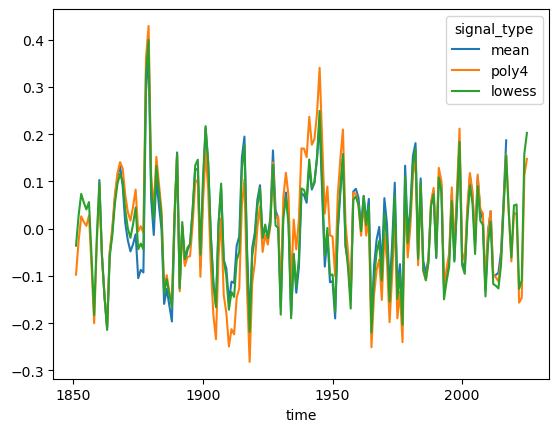

In [41]:
ds_no_trend.isel(**member_kwargs).plot(hue='signal_type');

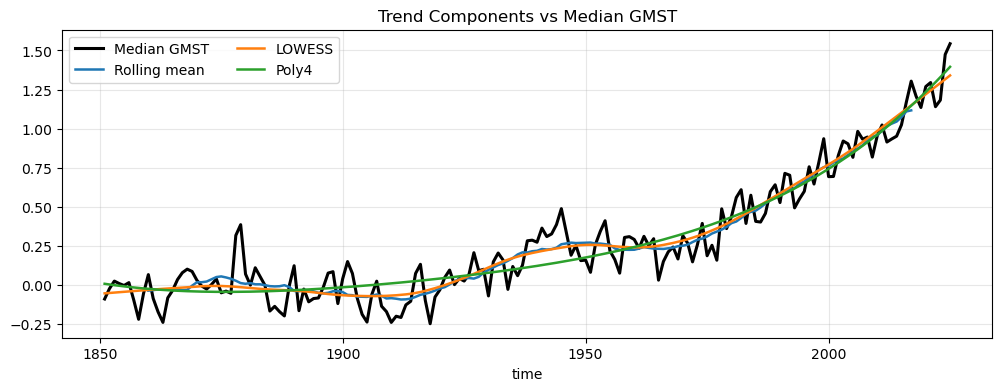

In [42]:
fig, ax = plt.subplots(figsize=(12, 4))
smean_anom_ds.plot(ax=ax, color='black', linewidth=2.2, label='Median GMST')

signal_ds.isel(**member_kwargs).sel(signal_type='mean').plot(ax=ax, linewidth=1.8, label='Rolling mean')
signal_ds.isel(**member_kwargs).sel(signal_type='lowess').plot(ax=ax, linewidth=1.8, label='LOWESS')
signal_ds.isel(**member_kwargs).sel(signal_type='poly4').plot(ax=ax, linewidth=1.8, label='Poly4')

ax.set_title('Trend Components vs Median GMST')
ax.grid(alpha=0.3)
ax.legend(ncol=2)



Generic interpretation used in this notebook:

- `S/N >= 1`: unusual
- `S/N >= 2`: unfamiliar
- `S/N >= 3`: unknown
- `S/N >= 5`: inconceivable

These labels are visualization aids and can be changed if your framing differs.


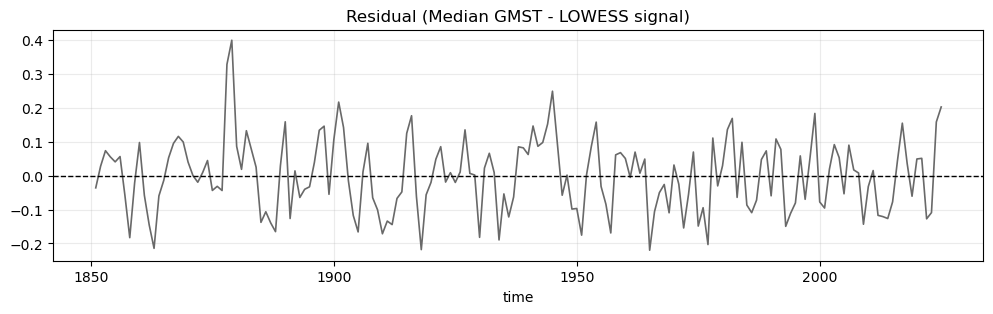

In [43]:
fig, ax = plt.subplots(figsize=(12, 3))
ds_no_trend.sel(signal_type='lowess').plot(ax=ax, color='dimgray', linewidth=1.2)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_title('Residual (Median GMST - LOWESS signal)')
ax.grid(alpha=0.25)


In [44]:
def format_timeseries_ax(ax):
    start_year = int(best_ds_smean_median.time.dt.year.min())
    end_year = int(best_ds_smean_median.time.dt.year.max())
    tick_start = 25 * (start_year // 25)

    ax.set_xlim(start_year - 3, end_year + 1)
    ax.set_xticks(np.arange(tick_start, end_year + 1, 25))
    ax.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])

    # Keep visual style consistent with the polished figure theme
    ax.set_facecolor('#f1f1f1')
    ax.grid(True, linestyle='-', color='#c6c6c6', alpha=0.55)


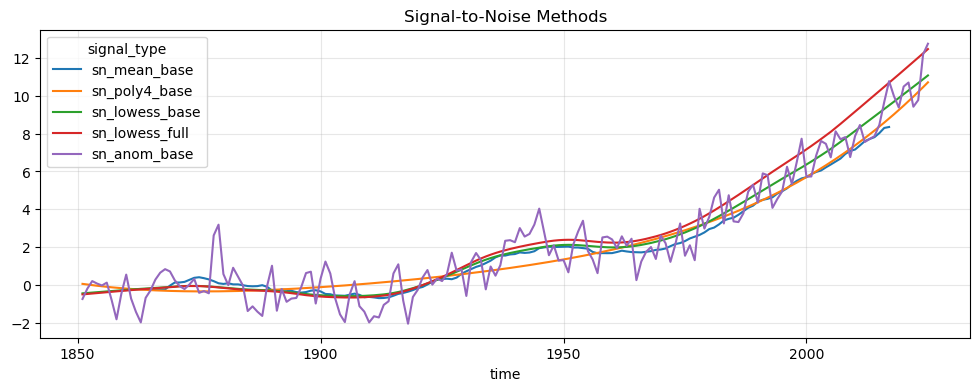

In [45]:
# Diagnostic plot
fig, ax = plt.subplots(figsize=(12, 4))
sn_multi_ds.isel(member_kwargs).plot(ax=ax, hue='signal_type')
ax.set_title('Signal-to-Noise Methods')
ax.grid(alpha=0.3)

## Metric Families

- **p-value metrics** (`ks`, `ttest`) detect distributional shifts.
- **overlap metrics** (`frac`, `hd`) quantify distribution separation.
- **new normal** (`nn`) tracks sustained exceedance over baseline maximum.
- **probability ratio** (`pr`) tracks multiplicative change in event likelihood.


In [46]:
import toe_calc_variations
import toe_calc

In [47]:
smean_anom_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 1kB
-0.08897 -0.02272 0.02549 0.009677 -0.002542 ... 1.295 1.14 1.182 1.474 1.543
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [48]:
data_ds_window = (smean_anom_ds
                  .rolling(time=window, center=True, min_periods=window)
                  .construct('window_dim')
                  .persist()
                 ) 

base_period_window_ds = (base_period_anom_ds
                         .rename({'time':'window_dim'})
                         .persist()
                        )
wait(data_ds_window);
wait(base_period_window_ds);

## p-value methods

Both lines should show when each test starts indicating a statistically unusual state.


In [49]:
%%time
ks_ds = toe_calc_variations.ks(data_ds_window, base_period_window_ds)

CPU times: user 133 ms, sys: 19.6 ms, total: 152 ms
Wall time: 130 ms


In [50]:
ttest_ds = toe_calc_variations.ttest(data_ds_window, base_period_window_ds)

In [51]:
ks_ds

<xarray.DataArray 'ks' (time: 175)> Size: 1kB
0.4586 0.5445 0.6691 0.8159 0.8957 ... 1.061e-13 2.736e-13 7.296e-13 2.017e-12
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [52]:
ttest_ds

<xarray.DataArray 'ttest' (time: 175)> Size: 1kB
0.08229 0.1064 0.1558 0.2301 0.3056 ... 4.647e-28 1.224e-27 3.433e-27 1.701e-27
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

##  Overlap Metrics

`frac` typically decreases with emergence; `hd` typically increases.


In [53]:
data_max = smean_anom_ds.max().persist().values.item()
data_min = smean_anom_ds.min().persist().values.item()
x = toe_calc.create_x(bmin=data_min, bmax=data_max, num_points=1000)
print(x[:5], x[-5:], sep='\n')

[-0.84364237 -0.8406564  -0.83767044 -0.83468447 -0.8316985 ]
[2.12739684 2.13038281 2.13336878 2.13635475 2.13934072]


In [54]:
base_period_kde = toe_calc_variations._create_base_period_kde(base_period_anom_ds, x)

In [55]:
base_period_kde

<xarray.DataArray 'temperature' (x: 1000)> Size: 8kB
7.761e-125 1.285e-123 2.098e-122 3.379e-121 5.367e-120 ... 0.0 0.0 0.0 0.0 0.0
Dimensions without coordinates: x

In [56]:
frac_geom_ds = toe_calc_variations.fga(base_period_kde=base_period_kde, data_ds_window=data_ds_window)
hd_ds = toe_calc_variations.hd(base_period_kde=base_period_kde, data_ds_window=data_ds_window)

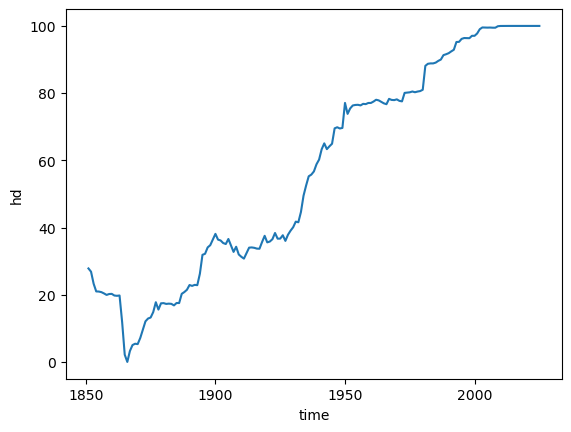

In [57]:
hd_ds.plot(**plotting_dict);

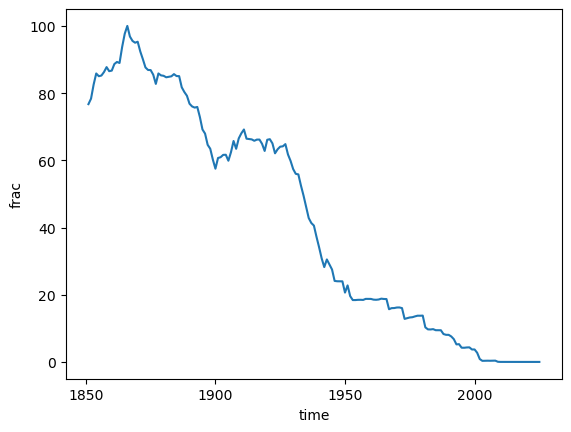

In [58]:
frac_geom_ds.plot(**plotting_dict);

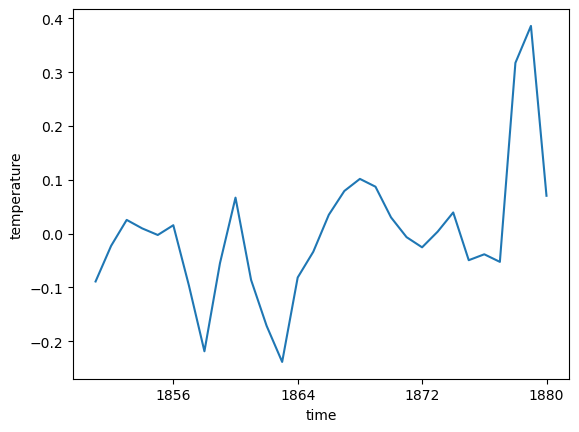

In [59]:
base_period_anom_ds.plot(**plotting_dict);

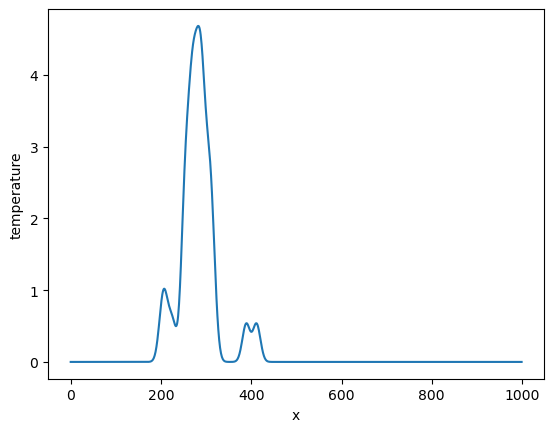

In [60]:
base_period_kde.plot(**plotting_dict);

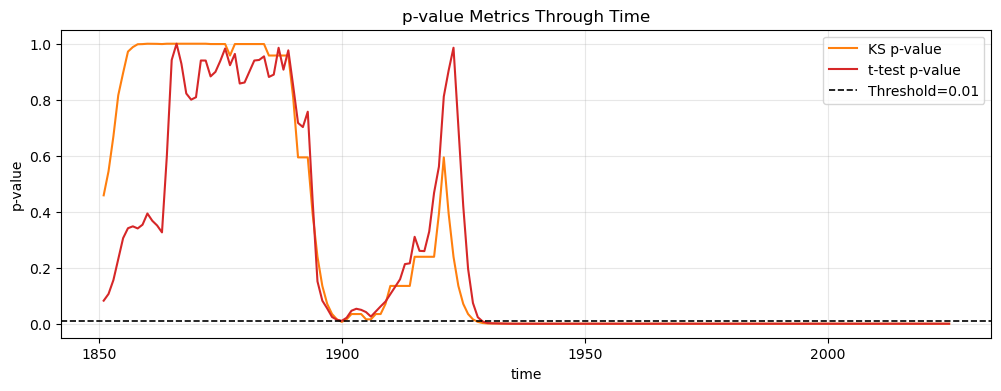

In [61]:
fig, ax = plt.subplots(figsize=(12, 4))
ks_ds.isel(member_kwargs).plot(ax=ax, label='KS p-value', color='tab:orange')
ttest_ds.isel(member_kwargs).plot(ax=ax, label='t-test p-value', color='tab:red')
ax.axhline(PVALUE_THESHOLD1, linestyle='--', color='k', linewidth=1.2, label=f'Threshold={PVALUE_THESHOLD1}')
ax.set_title('p-value Metrics Through Time')
ax.set_ylabel('p-value')
ax.grid(alpha=0.3)
ax.legend()


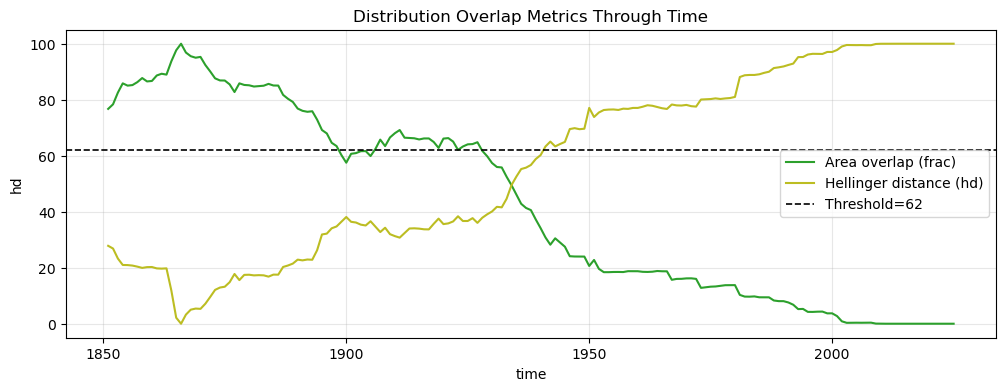

In [62]:
fig, ax = plt.subplots(figsize=(12, 4))
frac_geom_ds.isel(member_kwargs).plot(ax=ax, label='Area overlap (frac)', color='tab:green')
hd_ds.isel(member_kwargs).plot(ax=ax, label='Hellinger distance (hd)', color='tab:olive')
ax.axhline(OVERLAP_THRESHOLD, linestyle='--', color='k', linewidth=1.2, label=f'Threshold={OVERLAP_THRESHOLD}')
ax.set_title('Distribution Overlap Metrics Through Time')
ax.grid(alpha=0.3)
ax.legend()


## PR Construction

The first panel tracks rolling event probability (`p1`), and the second panel tracks `PR = p1/p0`.


## Probability Ratio (PR) Definition

Define event threshold from base climate quantile (`q=0.95` by default).

\[
PR(t) = rac{p_1(t)}{p_0}
\]

- `p0`: base-period event probability
- `p1(t)`: rolling event probability over time

`PR = 1` means no change in event likelihood; `PR > 1` means increased likelihood.


In [63]:
# Threshold from base period
pr_threshold = base_period_anom_ds.quantile(pr_event_quantile, dim='time')

# Event occurrence over full dataset
pr_event_da = xr.where(smean_anom_ds > pr_threshold, 1.0, 0.0)

# Base probability per member (from base period only)
p0 = xr.where(base_period_anom_ds > pr_threshold, 1.0, 0.0).mean(dim='time')
p0_safe = xr.where(p0 > 1e-6, p0, 1e-6)

# Rolling probability over full time series (per member)
p1 = pr_event_da.rolling(time=pr_window, center=True).mean()

# Probability ratio per member
pr_ds = (p1 / p0_safe).rename('pr')

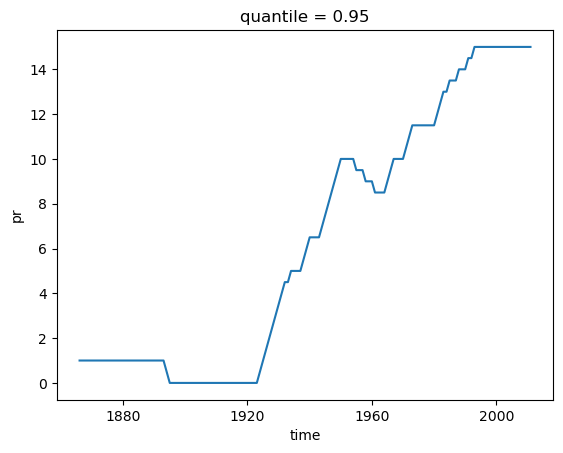

In [64]:
pr_ds.plot(**plotting_dict);

In [65]:
# new normal metric
base_max_value = base_period_anom_ds.max().values.item()
new_normal_ds = xr.where(rolling_20_ds > base_max_value, 1, 0)

In [66]:
pr_ds = pr_ds.compute()

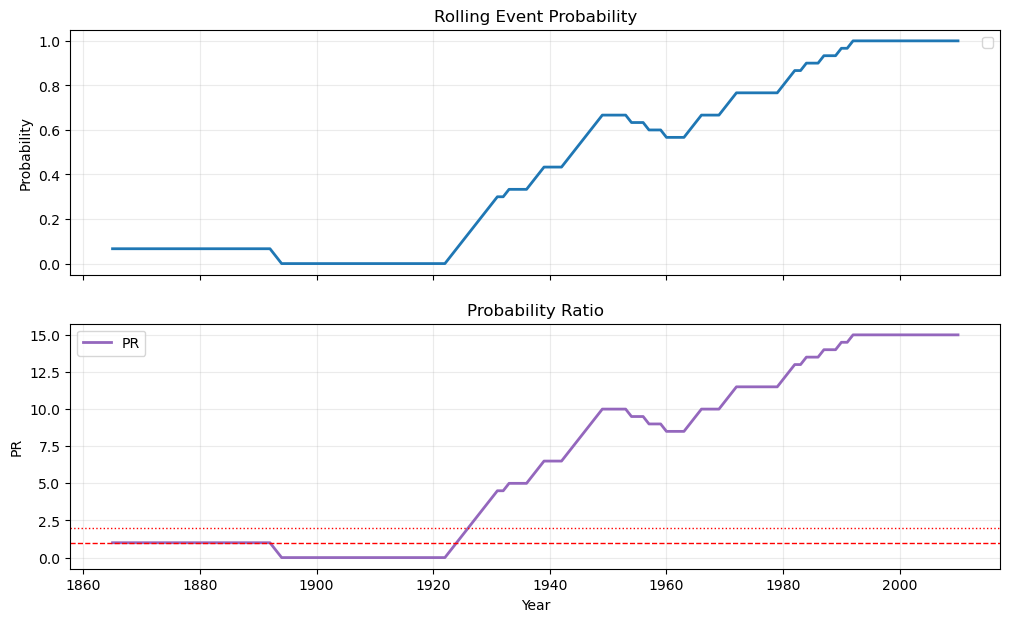

In [67]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

years = p1.time.dt.year.values
ax1.plot(years, p1.isel(member_kwargs).values, color='tab:blue', linewidth=2)
# ax1.axhline(p0.isel(member_kwargs).values, color='tab:orange', linestyle='--', linewidth=1.5, label=f'p0={p0:.3f}')
ax1.set_ylabel('Probability')
ax1.set_title('Rolling Event Probability')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(pr_ds.time.dt.year.values, pr_ds.isel(member_kwargs).values, color='tab:purple', linewidth=2, label='PR')
ax2.axhline(1, color='red', linestyle='--', linewidth=1)
ax2.axhline(2, color='red', linestyle=':', linewidth=1)
ax2.set_ylabel('PR')
ax2.set_xlabel('Year')
ax2.set_title('Probability Ratio')
ax2.grid(alpha=0.25)
ax2.legend()


# Time of Emergence (ToE)


 Combined Metric Dataset

A quick subset plot to verify everything merged correctly before ToE extraction.


In [68]:
# standardize names for merge/readability
ks_ds.name = 'ks'
ttest_ds.name = 'ttest'
frac_geom_ds.name = 'frac'
hd_ds.name = 'hd'
new_normal_ds.name = 'nn'

In [69]:
# merge metrics

toe_metrics_ds = xr.merge([
    ks_ds,
    ttest_ds,
    sn_multi_ds.to_dataset('signal_type'),
    frac_geom_ds,
    hd_ds,
    new_normal_ds,
    pr_ds,
])

toe_metrics_ds = toe_metrics_ds.isel(time=slice(None, -int(window / 2))).compute()
toe_metrics_ds = toe_metrics_ds.compute()

In [70]:
toe_metrics_ds

<xarray.Dataset> Size: 15kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
    quantile        float64 8B 0.95
Data variables:
    ks              (time) float64 1kB 0.4586 0.5445 ... 1.691e-17 1.691e-17
    ttest           (time) float64 1kB 0.08229 0.1064 ... 3.053e-29 2.507e-29
    sn_mean_base    (time) float64 1kB nan nan nan nan ... 6.927 7.085 7.16
    sn_poly4_base   (time) float64 1kB 0.06331 0.02838 -0.004633 ... 7.192 7.378
    sn_lowess_base  (time) float64 1kB -0.4376 -0.418 -0.3981 ... 7.945 8.137
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom_base    (time) float64 1kB -0.7351 -0.1877 0.2106 ... 6.76 7.872
    frac            (time) float64 1kB 76.72 78.36 82.55 ... 0.04367 0.005561
    hd              (time) float64 1kB 27.82 26.85 23.27 ... 99.47 99.91 99.98
    nn              (time) int64 1kB 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    pr              (time) float64 1kB nan nan nan nan ... 15.0 15.0 15.0 15.0

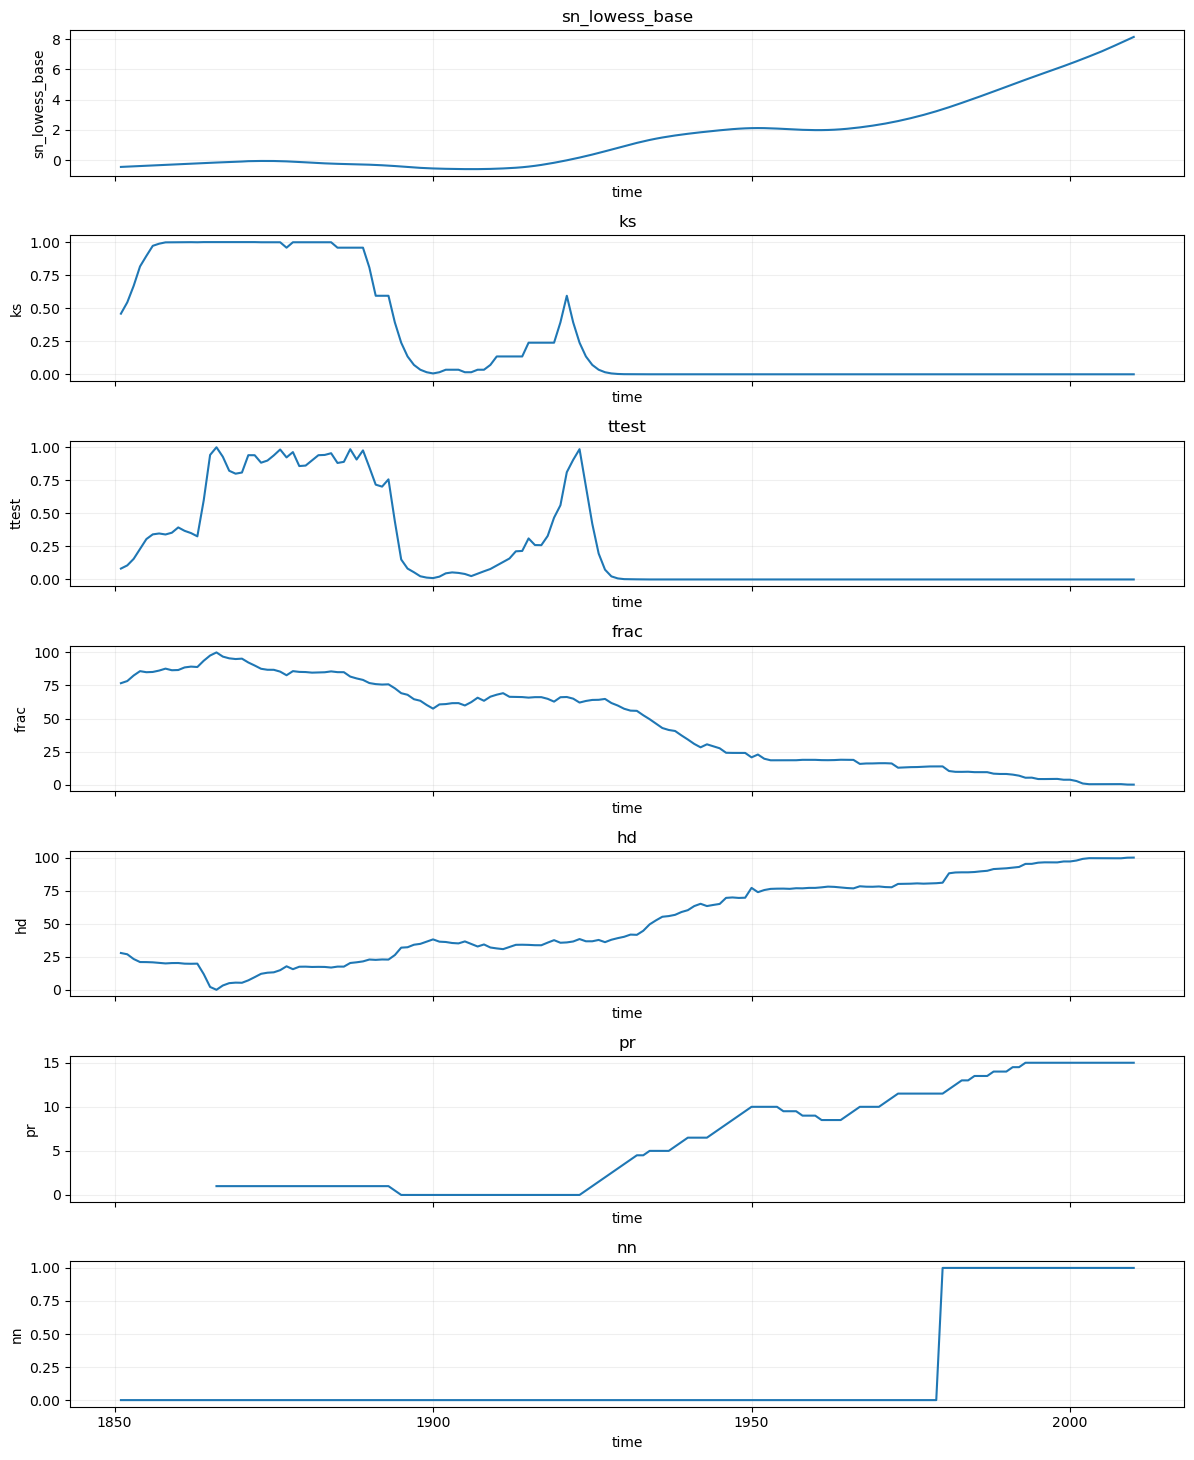

In [71]:
preview_vars = [v for v in ['sn_lowess_base', 'ks', 'ttest', 'frac', 'hd', 'pr', 'nn'] if v in toe_metrics_ds.data_vars]
fig, axes = plt.subplots(len(preview_vars), 1, figsize=(12, 2.1 * len(preview_vars)), sharex=True)
if len(preview_vars) == 1:
    axes = [axes]
for ax, name in zip(axes, preview_vars):
    toe_metrics_ds[name].plot(ax=ax)
    ax.set_title(name)
    ax.grid(alpha=0.2)
plt.tight_layout()


ToE Rule Set

Permanent exceedance is computed per metric with method-specific thresholds:

- S/N metrics: `|S/N| >= 1`
- KS / t-test: `p < PVALUE_THESHOLD1`
- Fraction overlap: `<= OVERLAP_THRESHOLD`
- Hellinger distance: `>= OVERLAP_THRESHOLD`
- Probability ratio: `PR >= 2`
- New normal: boolean permanent exceedance

Final ToE years are clipped to the available data range.


In [72]:
# toe_metrics_ds = toe_metrics_ds.chunk({'time':-1, 'member':10}).persist()
# wait(toe_metrics_ds);

In [73]:
import toe_calc as toe

In [74]:
toe_metrics_ds

<xarray.Dataset> Size: 15kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
    quantile        float64 8B 0.95
Data variables:
    ks              (time) float64 1kB 0.4586 0.5445 ... 1.691e-17 1.691e-17
    ttest           (time) float64 1kB 0.08229 0.1064 ... 3.053e-29 2.507e-29
    sn_mean_base    (time) float64 1kB nan nan nan nan ... 6.927 7.085 7.16
    sn_poly4_base   (time) float64 1kB 0.06331 0.02838 -0.004633 ... 7.192 7.378
    sn_lowess_base  (time) float64 1kB -0.4376 -0.418 -0.3981 ... 7.945 8.137
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom_base    (time) float64 1kB -0.7351 -0.1877 0.2106 ... 6.76 7.872
    frac            (time) float64 1kB 76.72 78.36 82.55 ... 0.04367 0.005561
    hd              (time) float64 1kB 27.82 26.85 23.27 ... 99.47 99.91 99.98
    nn              (time) int64 1kB 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    pr              (time) float64 1kB nan nan nan nan ... 15.0 15.0 15.0 15.0

In [75]:
OVERLAP_THRESHOLD

62

In [76]:
hd_ds = hd_ds/100

In [77]:
HD_THESHOLD = np.sqrt(1-OVERLAP_THRESHOLD/100)
HD_THESHOLD

0.6164414002968976

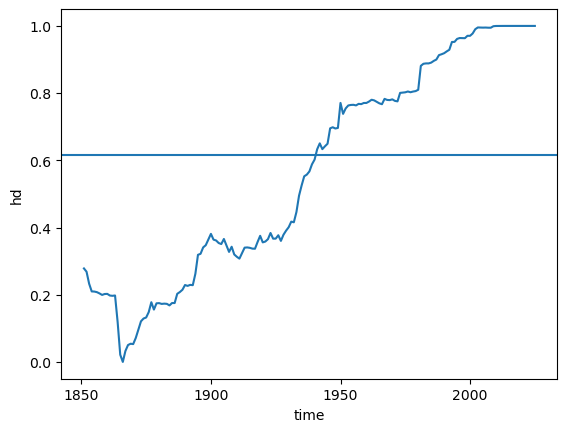

In [78]:
fig, ax = plt.subplots()
hd_ds.plot(ax=ax)
ax.axhline(HD_THESHOLD)

In [79]:
sn_vars = [var for var in toe_metrics_ds.data_vars if var.startswith('sn_')]
sn_toe_ds = toe.get_permanent_exceedance(
    np.abs(toe_metrics_ds[sn_vars]),
    threshold=1,
    greater=True,
).compute()
nn_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['nn'], threshold=0.5, greater=True)
ks_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ks'], threshold=PVALUE_THESHOLD1, greater=False)
ttest_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ttest'], threshold=PVALUE_THESHOLD1, greater=False)
frac_geom_toe_ds = toe.get_permanent_exceedance(frac_geom_ds, threshold=OVERLAP_THRESHOLD, greater=False)
hd_toe_ds = toe.get_permanent_exceedance(hd_ds, threshold=HD_THESHOLD, greater=True)
pr_toe_ds = toe.get_permanent_exceedance(pr_ds, threshold=2.0, greater=True)

In [80]:
# merge TOE estimates

toe_ds = xr.merge([
    sn_toe_ds,
    ks_toe_ds,
    ttest_toe_ds,
    frac_geom_toe_ds,
    hd_toe_ds,
    nn_toe_ds,
    pr_toe_ds,
])

max_year = int(smean_anom_ds.time.dt.year.max())
toe_ds = xr.where(toe_ds <= max_year, toe_ds, np.nan).compute()
wait(toe_ds);

# toe_ds.to_pandas()


In [81]:
toe_df = toe_ds.to_pandas()
toe_df.head(10)

sn_mean_base      1932.0
sn_poly4_base     1941.0
sn_lowess_base    1930.0
sn_lowess_full    1929.0
sn_anom_base      1965.0
ks                1927.0
ttest             1928.0
frac              1927.0
hd                1940.0
nn                1979.0
dtype: float64

(1890.0, 2010.0)

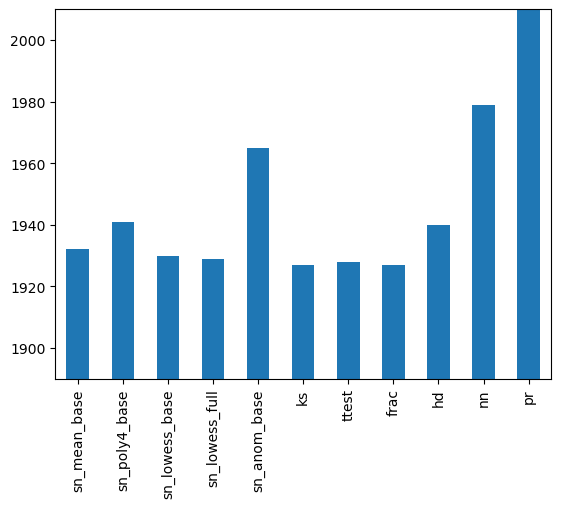

In [82]:
toe_ds.isel(member_kwargs).to_pandas().plot.bar()
plt.ylim(1890, 2010)

# Core ToE Panel (`toe_plots`)


## Functions

In [83]:

from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.ticker as mticker

In [84]:
# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style."""
    plt.rcParams.update({
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        "mathtext.fontset":      "dejavusans",

        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "bold",
        "axes.labelpad":         3,

        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.9,
        "legend.edgecolor":      "none",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,
        "legend.fancybox":       False,

        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        "patch.linewidth":       0.75,
    })
apply_nature_rcparams()



In [85]:
"""
Plotting functions for the ToE method schematic figure (fig_02).

Layout (v5):
  Row 1  – full-width GMST anomaly + signal overlays + ToE markers
  Row 2  – full-width S/N ratio (matched x-axis to Row 1)
  Row 3  – KS test | T-test                           (test-statistic pair)
  Row 4  – AO + HD combined | PR tail illustration    (distributional pair)
  Row 5  – full-width PR + New Normal threshold time-series

Style via S dict.  No rcParams side effects.
Organisation: style → helpers → compute → plot → annotate → assembly.
"""

# ══════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════

def _shade_base(ax, base_period):
    c = S["base_color"]
    ax.axvspan(base_period[0], base_period[1], color=c, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.55), xycoords = ('data', 'axes fraction'),
                fontsize=S["text"], ha="center", va='top',
                color=S["base_color"], fontweight="bold")


def _shade_comparison(ax, center_year, comparison_year, half_window=15):
    c = S["comp_color"]
    ax.axvspan(center_year - half_window, center_year + half_window,
               color=c, alpha=0.06, zorder=0)
    ax.axvline(center_year - half_window, color=c, lw=0.5, ls=":", alpha=0.5)
    ax.axvline(center_year + half_window, color=c, lw=0.5, ls=":", alpha=0.5)
    ax.annotate("Comparison\nWindow", xy=(comparison_year, 0.55),
                    fontsize=S["text"], ha="center", va='top',
                    color=S["comp_color"], fontweight="bold")


def _grid(ax):
    ax.grid(True, ls="--", alpha=0.5)


def _ticks(ax):
    ax.tick_params(axis="both", labelsize=S["tick"], direction="out")
    # Major ticks every 20 years
    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
    
    # Minor ticks every 5 years
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))


def _draw_kde(ax, x, kb, kf, *, labels=True):
    ax.plot(x, kb, color=S["base_color"], lw=S["lw"], alpha=0.5,
            label=r"$f_1(x): $Base Period" if labels else None)
    ax.plot(x, kf, color=S["future_color"], lw=S["lw"], alpha=0.5,
            label=r"$f_2(x)$: Future Climate" if labels else None)

# ══════════════════════════════════════════════════════════════════════════
# Row 1 — GMST + signals + ToE
# ══════════════════════════════════════════════════════════════════════════

def plot_gmst_and_toe(ax, smean_anom, toe_df, base_period, *,
                      smean_anom_ens=None, signal_ds=None,
                      comparison_year=None,
                      half_window=15):
    """GMST anomaly time-series with signal overlays and ToE markers."""
    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    if smean_anom_ens is not None:
        n = smean_anom_ens.sizes.get("member", 1)
        if "member" in smean_anom_ens.dims and n > 1:
            for i in range(n):
                ax.plot(time, smean_anom_ens.isel(member=i).values,
                        color=S["ensemble_color"], alpha=S["ensemble_alpha"],
                        lw=S["member_lw"])

    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)


    _shade_base(ax, base_period)

    if comparison_year is not None:
        _shade_comparison(ax, comparison_year, comparison_year, half_window)


    ax.axhline(0, color=S["base_color"], ls="--", lw=S["lw"] * 0.6,
               alpha=0.5, zorder=1)

    for metric, year in toe_df.items():
        METRIC_STYLE = toe_plots.TEST_STYLES.get(metric)
        color = METRIC_STYLE["color"]
        marker = METRIC_STYLE["marker"]
        linestyle = ':' if metric in ['ks', 'ttest'] else 'solid'
        label = (toe_plots.METRIC_NAME_MAP_SHORT.get(metric, metric).replace("base", "").replace(",", ""))
        
        yval = arr[time == year][0]

        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, linewidth=STYLE['lw'],
                color=color, marker=marker, linestyle=linestyle)
        ax.scatter([year], [yval], color=color, s=S["marker_s"], marker=marker,
                   zorder=100, edgecolors="white", linewidths=0.6)

    leg = ax.legend(loc="upper left", ncol=5, **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2})
    leg.set_title("Time of Emergence (ToE)", prop=LEGEND_PROP)
    ax.set_title("Time of Emergence (ToE) of Global Mean Surface Temperature (GMST)", fontsize=S["title"])

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(-0.35, 1.5)
    _grid(ax)
    _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 2 — S/N ratio
# ══════════════════════════════════════════════════════════════════════════

def plot_sn_ratio(ax, toe_metrics_ds, base_period=None, *, overlap_vars=None):
    """S/N ratio curves with threshold lines and optional overlap twin."""
    sn_vars = [k for k in list(toe_metrics_ds.data_vars)
               if k.startswith("sn_") and k in toe_metrics_ds.data_vars]

    for i, metric in enumerate(sn_vars):
        METRIC_STYLE = toe_plots.TEST_STYLES.get(metric)
        color = METRIC_STYLE["color"]
        marker = METRIC_STYLE["marker"]
        linestyle = ':' if metric in ['ks', 'ttest'] else 'solid'
        label = (toe_plots.METRIC_NAME_MAP_SHORT.get(metric, metric).replace("base", "").replace(",", ""))

        # color = toe_plots.TEST_STYLES[name]["color"]
        alpha = 0.6 if "anom" in metric else 0.9
        zorder = 1 if "anom" in metric else 5 + i
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[metric].values,
                color=color, ls="solid", alpha=alpha, zorder=zorder,
                label=label,#toe_plots.METRIC_NAME_MAP[name],
                lw=S["lw"])

    # tkw = dict(ls="--", color=S["future_color"], lw=S["lw"] * 0.55, alpha=0.65, zorder=0)
    
    for yval, label in [(1, "Unusual"), (2, "Unfamiliar"),
                        (3, "Unknown"), (5, "Inconceivable")]:
        ax.axhline(yval, **toe_plots.THESHOLD_STYLE)
        ax.annotate(label, xy=(1.0, yval-0.12), xycoords=("axes fraction", "data"),
                    xytext=(-4, 2), textcoords="offset points",
                    ha="right", va="bottom", size=S["text"] - 0.5,
                    color=S["future_color"], annotation_clip=False, zorder=200)

    ax.set_ylabel("S/N Ratio", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=S["title"])
    ax.set_ylim(-2, 10)
    leg = ax.legend( loc="upper center", ncol=2, **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2})
    leg.set_title("Signal Estimation Method", prop=LEGEND_PROP)

    _grid(ax)
    _ticks(ax)
    if base_period: _shade_base(ax, base_period)


    ax_right = None
    if overlap_vars:
        if isinstance(overlap_vars, str): overlap_vars = [overlap_vars]
        for overlap_var in overlap_vars:
            ov = toe_metrics_ds[overlap_var]
            ax_right = ax.twinx()
            yrs, vals = ov.time.dt.year.values, ov.values

            color = toe_plots.TEST_STYLES.get(overlap_var, {"color": "black"})["color"]
            label = label = toe_plots.METRIC_NAME_MAP_SHORT.get(overlap_var, overlap_var)

            ax_right.plot(yrs, vals, lw=S["lw"], color=color, label=label, zorder=1)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=S["label"],
                            color=S["overlap_color"])
        ax_right.tick_params(axis="y", labelcolor=S["overlap_color"],
                             labelsize=S["tick"])
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(S["overlap_color"])
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_right.get_legend_handles_labels()
        leg = ax.legend(h1 + h2, l1 + l2, **LEGEND_KWARGS, loc="upper left", ncol=5)
        
        leg.set_title("Signal Estimation Method", prop=LEGEND_PROP)
  
        # ax.legend(h1 + h2, l1 + l2, fontsize=S["legend"], loc="upper left")

    return ax, ax_right


# ══════════════════════════════════════════════════════════════════════════
# Row 3 — Test-statistic pair: KS | T-test
# ══════════════════════════════════════════════════════════════════════════

def plot_ks_test(ax, smean_anom, base_period, emergence_year, window):
    """KS-test CDFs and max-statistic marker."""
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    emrg = smean_anom.sel(
        time=slice(str(emergence_year - window//2),
                   str(emergence_year + window//2))).values
    ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
    ks = ks_2samp(base, emrg)

    ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_1(x)$: Base Period")
    ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_2(x)$: Future Period")

    mx = ks.statistic_location
    ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
            color=S["median_color"], ls="--", lw=S["lw"], label='KS Statistic (D)')

    ax.annotate(
        r"$D = \sup_x |F_1 - F_2|$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set_ylabel("Cumulative Density", fontsize=S["label"])
    ax.set_ylim(0, 1.02)
    ax.set_xlim(-.25, 0.35)
    ax.set_title("Kolmogorov-Smirnov (KS) Test", fontsize=S["title"])
    
    ax.legend(loc="upper left", **LEGEND_KWARGS)
    # _ticks(ax)
    _grid(ax)


def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
                     *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """T-test: KDE curves with mean/std markers."""
    _draw_kde(ax, x, kb, kf, labels=True)

    mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
    sb, sf = float(np.std(base_arr)), float(np.std(future_arr))

    yb = kb[np.argmin(np.abs(x - mb))]
    yf = kf[np.argmin(np.abs(x - mf))]

    ax.plot([mb, mb], [0, yb], color=S["base_color"],   lw=S["lw"]*0.7)
    ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"]*0.7)

    ax.annotate(r"$\mu_1$", xy=(mb, yb + 0.35), ha="center",
                color=S["base_color"], fontsize=S["text"], fontweight='bold')
    ax.annotate(r"$\mu_2$", xy=(mf, yf + 0.35), ha="center",
                color=S["future_color"], fontsize=S["text"], fontweight='bold')

    for x_pos, kde, color in [
        (mb - sb, kb, S["base_color"]),
        (mb + sb, kb, S["base_color"]),
        (mf - sf, kf, S["future_color"]),
        (mf + sf, kf, S["future_color"])
    ]:
        y_top = kde[np.argmin(np.abs(x - x_pos))]
        ax.plot([x_pos, x_pos], [0, y_top], color=color,
                lw=S["lw"]*0.7, ls="--", alpha=1)

    yb_sig = kb[np.argmin(np.abs(x - (mb + sb)))]
    yf_sig = kf[np.argmin(np.abs(x - (mf + sf)))]
    ax.annotate(r"$\sigma_1$", xy=(mb - sb, yb_sig),
                ha="center", color=S["base_color"], fontsize=S["text"], fontweight='bold')
    ax.annotate(r"$\sigma_2$", xy=(mf + sf, yf_sig + 0.1),
                ha="center", color=S["future_color"], fontsize=S["text"], fontweight='bold')

    ax.annotate(
        r"$t = \frac{\mu_1-\mu_2}{\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend( loc="upper left", **LEGEND_KWARGS)
    _grid(ax)
    # _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 4 — Combined AO + HD  |  PR tail
# ══════════════════════════════════════════════════════════════════════════
def plot_overlap_hellinger_panel(ax, x, kb, kf, fga_overlap,
                                 *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Combined Area of Overlap + Hellinger Distance on one set of KDEs.
    Draws both distributions once, then overlays:
      - AO:  green filled region = min(f₁, f₂)
      - HD:  orange hatched region = (√f₁ − √f₂)²
    Two equation boxes sit side-by-side below the panel.
    """
    # ── KDE curves ──
    _draw_kde(ax, x, kb, kf, labels=True)

    # ── AO shading (green, solid fill) ──
    overlap = np.minimum(kb, kf)
    ax.fill_between(x, 0, overlap,
                    color=toe_plots.TEST_STYLES['frac']['color'], alpha=0.25,
                    label="Overlap (AO)", zorder=2)

    # ── HD squared differences (orange, hatched) ──
    sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
    ax.fill_between(x, 0, sq,
                    color=toe_plots.TEST_STYLES['hd']['color'], alpha=S["hd_alpha"],
                    hatch="////", edgecolor=toe_plots.TEST_STYLES['hd']['color'],
                    label="Square Differences\n(HD)", zorder=1)
    ax.plot(x, sq, color=toe_plots.TEST_STYLES['hd']['color'], lw=S["lw"] * 0.8, alpha=0.7, zorder=1)

    # ── Legend ──
    ax.legend(loc="upper left", fontsize=S["legend"], ncol=1, facecolor='none')

    # ── Equation boxes ──
    ax.annotate(
        r"$AO = \int \min(f_1, f_2)\,dx$",
        xy= (1, .6), xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )
    ax.annotate(
        r"$HD = \frac{1}{\sqrt{2}}\sqrt{\int(\sqrt{f_1}-\sqrt{f_2})^2\,dx}$",
        xy= (1, .96), xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim,
           ylabel="Probability\n" + r"$(\sqrt{f_1}-\sqrt{f_2})^2$",
           title="Area of Overlap (AO)\n&  Hellinger Distance (HD)")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    _grid(ax)
    return ax

def plot_pr_panel(ax, x, kb, kf, base_arr, future_arr,
                  *, xlim=(-0.8, 0.8), ylim=(0, 6),
                  event_quantile=0.95):
    """Probability Ratio — tail-area illustration."""
    _draw_kde(ax, x, kb, kf, labels=False)

    thresh = float(np.quantile(base_arr, event_quantile))
    ax.axvline(thresh, color=S["median_color"], ls="--", lw=S["lw"],
               alpha=0.7, label=f"Threshold\n({event_quantile:.0%} percentile)")

    mask = x >= thresh

    label_base=r"$p_{\text{Base Period}}$"
    label_future=r"$p_{\text{Future Climate}}$"
    ax.fill_between(x[mask], 0, kf[mask], color=S["future_color"],
                    alpha=0.25, label=label_future)
    ax.fill_between(x[mask], 0, kb[mask], color=S["base_color"],
                    alpha=0.7, label=label_base, hatch='////')
    annotate = rf'$PR = \dfrac{{p_{{\text{{Future Climate}}}}}}{{p_{{\text{{Base Period}}}}}}$'
    ax.annotate(
        annotate,
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="Probability Ratio (PR)")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", **LEGEND_KWARGS)
    _grid(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 5 — PR + New Normal threshold time-series (full width)
# ══════════════════════════════════════════════════════════════════════════

def plot_threshold_panel(ax, smean_anom, base_period, *,
                         rolling_da, event_quantile=0.95):
    """Threshold time-series: GMST + rolling mean + two threshold lines.

    Shows raw anomaly, rolling mean, and:
      - 95th percentile of base period  → PR threshold
      - Maximum of base period          → New Normal threshold
    Purple shading marks where the rolling mean exceeds the base max.
    """
    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values

    # Raw anomaly
    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)

    # Rolling mean
    rolling_line, = ax.plot(rolling_da.time.dt.year.values, rolling_da.values, lw=S["lw"], color=toe_plots.TEST_STYLES['nn']['color'],
            alpha=0.85, zorder=5, label="Rolling mean")

    # Base-period statistics
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    base_max = float(np.nanmax(base))
    base_q95 = float(np.nanquantile(base, event_quantile))

    _shade_base(ax, base_period)



    # 95th percentile → PR threshold
    pr_line = ax.axhline(base_q95, color=toe_plots.TEST_STYLES['pr']['color'], ls="--", lw=S["lw"]*0.7,
               alpha=0.8, zorder=3,
               label=f"Threshold\n({event_quantile:.0%} percentile)")

    # Max of base → New Normal threshold
    nn_line = ax.axhline(base_max, color=toe_plots.TEST_STYLES['nn']['color'], ls="-.", lw=S["lw"]*0.7,
               alpha=0.8, zorder=3,
               label="Base Period Maximum (NN)")

    # Shade where rolling mean > base max (NN emergence)
    mask_nn = rolling_da.values > base_max
    nn_fill = ax.fill_between(time, base_max, rolling_da.values,
                    where=mask_nn,
                    color=toe_plots.TEST_STYLES['nn']['color'], alpha=0.12, zorder=2,
                    label="Mean Greater than Base Perido Maximum")

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Probability Ratio (PR)  &  New Normal (NN) Thresholds",
                 fontsize=S["title"])
    # --- Split legends ---
    legend_pr = ax.legend(
        handles=[pr_line],
        labels=[f"Threshold ({event_quantile:.0%} percentile)"],
        **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2},
        loc="upper left",
        bbox_to_anchor=(0.18, 1.0),
        bbox_transform=ax.transAxes,
    )
    ax.add_artist(legend_pr)
    legend_pr.set_title('Probability Ratio', LEGEND_PROP)
    
    legend_nn = ax.legend(
        handles=[nn_line, nn_fill, rolling_line],
        labels=["Base Period Maximum", "Mean > Base Period Maximum", 'Rolling Average'],
        **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2},
        loc="upper center",
        bbox_to_anchor=(0.64, 1.0),
        bbox_transform=ax.transAxes,
    )
    legend_nn.set_title('New Normal', LEGEND_PROP)
    # ax.legend(fontsize=S["legend"], loc="upper center", ncol=2)
    _grid(ax)
    _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Orchestration
# ══════════════════════════════════════════════════════════════════════════

def plot_distributional_panels(ax_tt, ax_ao_hd, ax_pr,
                               smean_anom, emergence_year, fga_fn,
                               *, base_window=50, half_window=15):
    """Compute KDE data once and populate T-test, AO+HD, PR panels."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr = smean_anom.isel(time=slice(0, base_window)).values
    idx = emergence_year - start_year - half_window
    future_arr = smean_anom.isel(time=slice(idx, idx + 30)).values

    x, kf, kb, ov = fga_fn(base_arr, future_arr, return_all=True,
                            method_kwargs=dict(bw_method=0.2),
                            bmin=-0.6, bmax=0.6)

    plot_ttest_panel(ax_tt, x, kb, kf, base_arr, future_arr)
    plot_overlap_hellinger_panel(ax_ao_hd, x, kb, kf, ov)
    plot_pr_panel(ax_pr, x, kb, kf, base_arr, future_arr)


# ══════════════════════════════════════════════════════════════════════════
# Standalone helpers (not used in main fig)
# ══════════════════════════════════════════════════════════════════════════

def plot_event_probability(ax, years, p1, p0):
    ax.plot(years, p1, color=S["base_color"], lw=S["lw"],
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=S["future_color"], ls="--", lw=S["lw"],
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set(ylabel="Probability", title="Event Probability: Base vs Rolling")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax); _ticks(ax)


def plot_probability_ratio_ts(ax, years, pr):
    c = S["future_color"]
    ax.plot(years, pr, color=S["last_color"], lw=S["lw"],
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c, ls="--", lw=S["lw"] * 0.8)
    ax.axhline(2, color=c, ls=":", lw=S["lw"] * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02), color=c,
                fontsize=S["text"])
    ax.annotate("PR=2", xy=(years[5], 2.05), color=c, fontsize=S["text"])
    ax.set(ylabel="Probability Ratio", xlabel="Year",
           title="Probability Ratio Demonstration")
    ax.yaxis.label.set_size(S["label"])
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax); _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Annotation
# ══════════════════════════════════════════════════════════════════════════

def annotate_panels(axes, *, xy=(0.01, 1.03), xy_overrides=None):
    """Bold a), b), … panel labels."""
    xy_overrides = xy_overrides or {}
    for i, ax in enumerate(axes):
        pos = xy_overrides.get(i, xy)
        ax.annotate(f"{chr(97 + i)})", xy=pos, xycoords="axes fraction",
                    fontsize=S["panel"], fontweight="bold")

In [86]:
# ══════════════════════════════════════════════════════════════════════════
# Style
# ══════════════════════════════════════════════════════════════════════════

STYLE = {
    "base_color":      "steelblue",
    "future_color":    "firebrick",
    "median_color":    "#1a1a1a",
    "hd_alpha":        0.35,
    "comp_color":      "firebrick",     # comparison-window shading
    # Typography (pt)
    "title": 8, "label": 8, "text": 7, "legend":6.5 ,"tick": 7, "panel": 9,
    # Lines
    "lw": 1.7, "member_lw": 0.5, "marker_s": 18,
    # Annotation box position (axes fraction) for distributional panels
    "ann_xy": (.85, .55),
}

S = STYLE

LEGEND_KWARGS = dict(fontsize=S["legend"], labelspacing=0.25, handletextpad=0.4, framealpha=0.8)
LEGEND_PROP = {"size": S["legend"]*1.1, "weight": "bold"} 


main_metrics = [
    'sn_mean_base', 'sn_poly4_base', 'sn_lowess_base', 'sn_anom_base',
    'nn', 'pr', 'frac', 'hd', 'ks', 'ttest'
]

## Plot

In [87]:
if 'member' in list(ds.coords):
    toe_df = toe_df.T

In [88]:
toe_df

sn_mean_base      1932.0
sn_poly4_base     1941.0
sn_lowess_base    1930.0
sn_lowess_full    1929.0
sn_anom_base      1965.0
ks                1927.0
ttest             1928.0
frac              1927.0
hd                1940.0
nn                1979.0
pr                2024.0
dtype: float64

In [89]:
sn_multi_ds

<xarray.DataArray (signal_type: 5, time: 175)> Size: 7kB
nan nan nan nan nan nan nan nan ... 9.98 9.38 10.48 10.7 9.421 9.77 12.18 12.75
Coordinates:
  * signal_type  (signal_type) object 40B 'sn_mean_base' ... 'sn_anom_base'
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

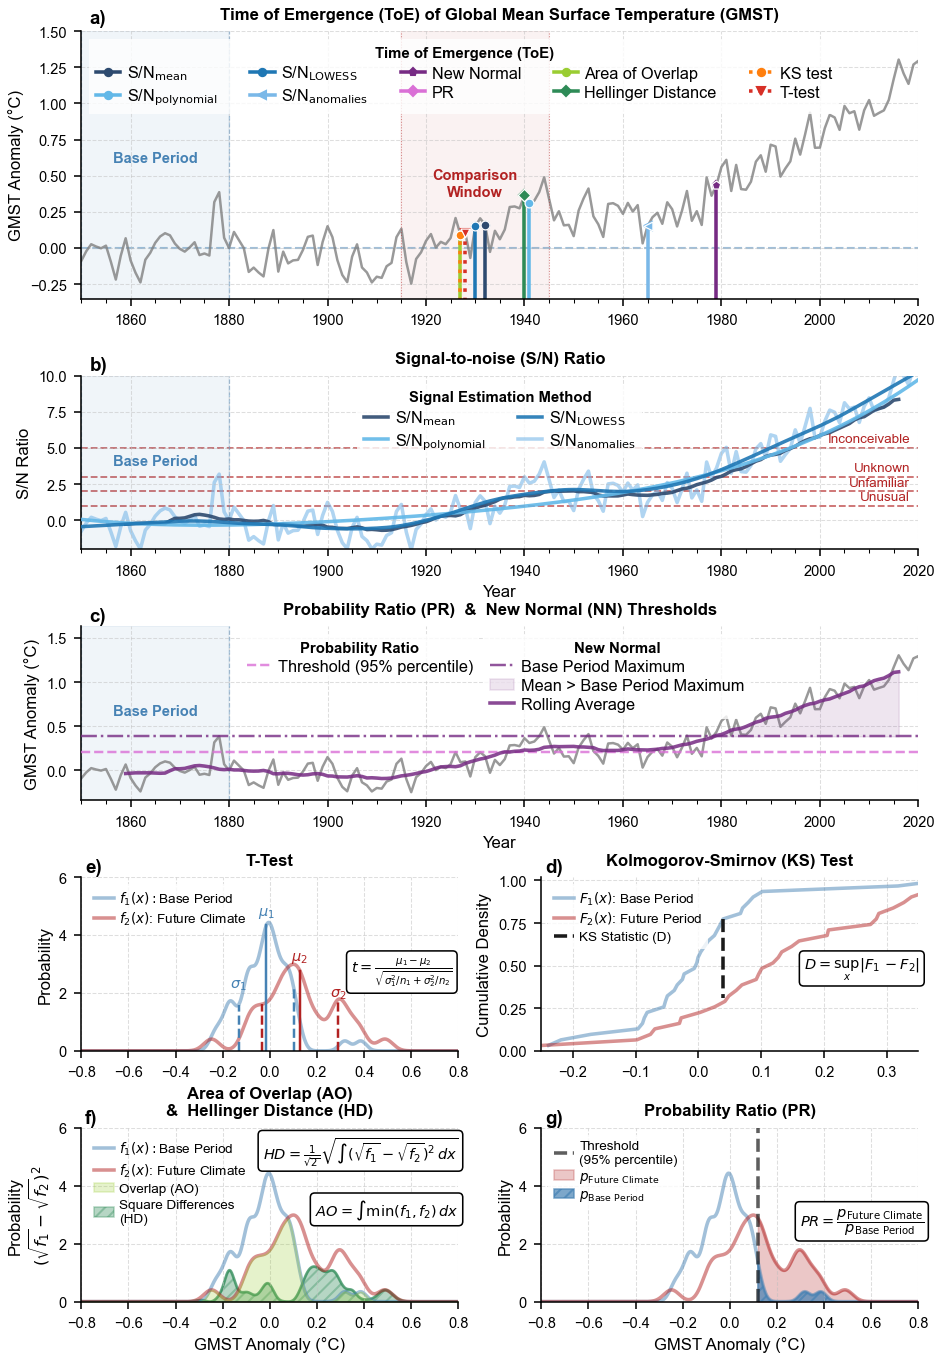

In [93]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic  (v5)
# ═══════════════════════════════════════════════════════════════════════════
#
#   Row 1  GMST anomaly + signal overlays + ToE markers    [full width]
#   Row 2  S/N ratio time-series                           [full width]
#   Row 3  KS test  |  T-test                              [test-stat pair]
#   Row 4  AO + HD combined  |  PR tail                    [distributional]
#   Row 5  PR + NN threshold time-series                   [full width]
#
# ═══════════════════════════════════════════════════════════════════════════
reload(toe_plots)
# ── 1. Build figure / GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 11)) # 12.5

gs = gridspec.GridSpec(
    5, 1,
    height_ratios=[1.0, 0.65, 0.65, 0.65, 0.65],
    hspace=0.4, wspace=0.2
)

ax_gmst = fig.add_subplot(gs[0])          # Row 1 – full width
ax_sn   = fig.add_subplot(gs[1])          # Row 2 – full width

# Row 3 – test-statistic pair
row3 = gs[3].subgridspec(1, 2, wspace=0.22)
ax_tt = fig.add_subplot(row3[0])
ax_ks = fig.add_subplot(row3[1])

# Row 4 – AO+HD combined | PR tail
row4 = gs[4].subgridspec(1, 2, wspace=0.22)
ax_ao_hd = fig.add_subplot(row4[0])
ax_pr    = fig.add_subplot(row4[1])

# Row 5 – full-width threshold time-series
ax_thre = fig.add_subplot(gs[2])

# ── 2. Determine the comparison-window year ──────────────────────────────
emergence_year = int(toe_ds['sn_lowess_base'].isel(member_kwargs).values.item())
# ── 3. Draw panels ───────────────────────────────────────────────────────

# Row 1: GMST + signal overlays + ToE markers
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,
    toe_df.loc[main_metrics],
    base_period_tuple,
    comparison_year=emergence_year,
    half_window=15,
)

# Row 2: S/N ratio
plot_sn_ratio(
    ax_sn,
    sn_multi_ds.to_dataset(dim='signal_type')[['sn_mean_base', 'sn_poly4_base', 'sn_lowess_base', 'sn_anom_base']].isel(member_kwargs),
    base_period=base_period_tuple,
    # overlap_vars=['frac', 'hd'],
)

# ax_sn.set_yticks(np.arange(-2, 10))

plot_distributional_panels(
    ax_tt, ax_ao_hd, ax_pr,
    smean_anom_ds,
    emergence_year=emergence_year,
    fga_fn=toe.fractional_geometric_area,
)

plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=emergence_year,
    window=window
)


# Row 5: PR + New Normal threshold time-series
plot_threshold_panel(
    ax_thre, smean_anom_ds, base_period_tuple,
    rolling_da=signal_ds.sel(signal_type='mean'), event_quantile=0.95,
)

# ── 4. Axis limits & labels ──────────────────────────────────────────────
for ax in [ax_gmst, ax_sn, ax_thre]:
    ax.set_xlim(1850, 2020)

# x-labels: only bottom panel in each column
ax_ks.set_xlabel("")
ax_tt.set_xlabel("")
ax_ao_hd.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])
ax_pr.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])

# ── 5. Panel letters ─────────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_thre, ax_ks, ax_tt, ax_ao_hd, ax_pr]
annotate_panels(all_axes)

fig.savefig('fig_02.png')